I got Cursor to write me a tracer. Let's try it out.

In [1]:
from tracer import Tracer
import sys

t = Tracer(max_spans=1000)
with t.trace():
    x = 0

    def foo(n):
        global x
        x = 0
        for i in range(n):
            bar(i)
        print("foo")

    def bar(k):
        global x
        x = k
        print(k, file=sys.stderr)

    def baz(a, b):
        return a + b

    def qux(x):
        return 2 * x

    foo(3)
    print(baz(qux(['x', 'y']), qux(['z'])))

[trace] = t.traces()
print("*"*50, f"Spans ({len(trace.spans)})", "*"*50)
for span in trace.spans:
	print(span)
print("*"*50, "Stdout", "*"*50)
print(trace.stdout, end="")
print("*"*50, "Stderr", "*"*50)
print(trace.stderr, end="")

************************************************** Spans (39) **************************************************
type='line' line_number=6 line='x = 0' assignments={'x': '0'}
type='line' line_number=8 line='def foo(n):' assignments={}
type='line' line_number=15 line='def bar(k):' assignments={}
type='line' line_number=20 line='def baz(a, b):' assignments={}
type='line' line_number=23 line='def qux(x):' assignments={}
type='line' line_number=26 line='foo(3)' assignments={}
type='call' line_number=8 line='def foo(n):' arguments={'n': '3'}
type='line' line_number=10 line='x = 0' assignments={'x': '0'}
type='line' line_number=11 line='for i in range(n):' assignments={'i': '0'}
type='line' line_number=12 line='bar(i)' assignments={}
type='call' line_number=15 line='def bar(k):' arguments={'k': '0'}
type='line' line_number=17 line='x = k' assignments={'x': '0'}
type='line' line_number=18 line='print(k, file=sys.stderr)' assignments={}
type='return' line_number=18 line='print(k, file=sys.stde

Let's try using the tracer on `openai/openai_humaneval`.

In [2]:
%pip install datasets


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
from datasets import load_dataset

ds = load_dataset("openai/openai_humaneval", split="test")

t.clear()
src = "\n".join([
	ds[0]["prompt"],
	ds[0]["canonical_solution"],
	ds[0]["test"],
	f"check({ds[0]["entry_point"]})",
])
t.trace_str(src)
[trace] = t.traces()
print("*" * 50, f"Spans ({len(trace.spans)})", "*" * 50)
for span in trace.spans:
    print(span)

************************************************** Spans (568) **************************************************
type='line' line_number=1 line='from typing import List' assignments={'List': "_SpecialGenericAlias(_inst=False, _name='List', _nparams=1, _defaults=())"}
type='line' line_number=4 line='def has_close_elements(numbers: List[float], threshold: float) -> bool:' assignments={}
type='line' line_number=25 line="'author': 'jt'," assignments={}
type='line' line_number=26 line="'dataset': 'test'" assignments={}
type='line' line_number=24 line='METADATA = {' assignments={'METADATA': "{'author': 'jt', 'dataset': 'test'}"}
type='line' line_number=30 line='def check(candidate):' assignments={}
type='line' line_number=40 line='check(has_close_elements)' assignments={}
type='call' line_number=30 line='def check(candidate):' arguments={}
type='line' line_number=31 line='assert candidate([1.0, 2.0, 3.9, 4.0, 5.0, 2.2], 0.3) == True' assignments={}
type='call' line_number=4 line='def has_cl

Hm. This trace was really long. I'm hoping not all traces are like this.

In [4]:
%pip install matplotlib seaborn tqdm


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


100%|██████████| 164/164 [00:01<00:00, 142.36it/s]


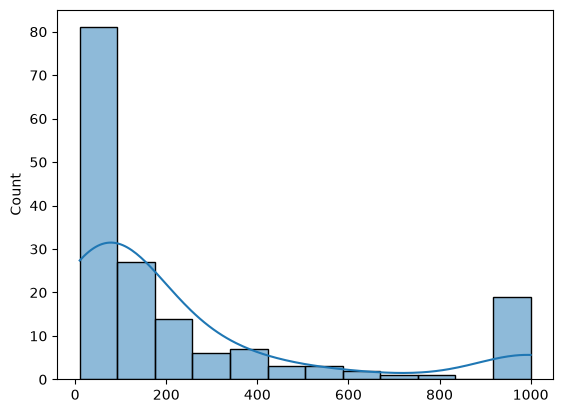

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

t.clear()
for prompt, canonical_solution, test, entry_point in tqdm(zip(
	ds["prompt"],
	ds["canonical_solution"],
	ds["test"],
	ds["entry_point"],
), total=len(ds)):
    src = "\n".join([
		prompt,
		canonical_solution,
		test,
		f"check({entry_point})",
	])
    t.trace_str(src)

x = [len(trace.spans) for trace in t.traces()]
sns.histplot(data=x, kde=True)
plt.show()

Looking at the distribution, I think I'm going to truncate the traces to at most 500 spans each.

In [6]:
import copy

traces = copy.deepcopy(t.traces())
count = 0
for trace in traces:
	if len(trace.spans) > 500:
		trace.spans = trace.spans[:500]
		count += 1
print(f"Truncated {count / len(traces):.2%} traces")

Truncated 15.85% traces
